# Customer Segmentation

This notebook applies K-Means clustering to group bank customers into behavioural personas. These personas will later support churn analysis, dashboard segmentation, and retention strategy recommendations.

In [1]:
# imports
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

# load data
df = pd.read_csv("../data/cleaned_bank_churn.csv")

In [2]:
# select features
cluster_features = [
    "Age",
    "Balance",
    "EstimatedSalary",
    "CreditScore",
    "Tenure",
    "NumOfProducts",
    "IsActiveMember",
    "SatisfactionScore"
]

In [3]:
# scale
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df[cluster_features]
)

In [4]:
# elbow method
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

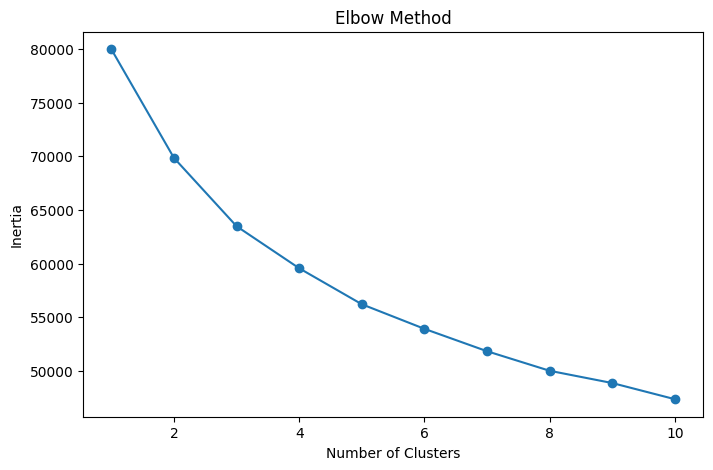

In [5]:
# plot
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

# Customer Segmentation

K-Means clustering was used to identify distinct customer personas within the bank's customer base.

The Elbow Method suggests that four clusters provide a reasonable balance between model complexity and within-cluster similarity. Therefore, k=4 was selected for customer segmentation.

In [ ]:
# clsuters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df["Cluster"].value_counts().sort_index()

Cluster
0    2875
1    1116
2    3249
3    2760
Name: count, dtype: int64

In [ ]:
# cluster profile table
cluster_profile = (
    df.groupby("Cluster")[
        cluster_features + ["Exited"]
    ]
    .mean()
    .round(2)
)

cluster_profile

,Age,Balance,EstimatedSalary,CreditScore,Tenure,NumOfProducts,IsActiveMember,SatisfactionScore,Exited
Cluster,,,,,,,,,
0,35.30,107780.59,100780.15,653.12,4.83,1.29,1.00,3.03,0.13
1,59.87,75759.69,94891.97,653.55,4.95,1.43,0.83,3.04,0.36
2,37.49,105909.12,101663.10,647.22,5.08,1.27,0.00,3.00,0.29
3,35.91,9544.62,99621.96,650.50,5.14,2.13,0.49,3.00,0.12


## Cluster Interpretation

The K-Means model identified four customer groups with different behavioural patterns.

| Cluster | Suggested Persona | Key Characteristics | Churn Risk |
|---|---|---|---|
| 0 | Active High-Balance Customers | Younger customers, high balance, fully active, lower churn rate | Low |
| 1 | Older At-Risk Customers | Oldest group, moderately high balance, higher churn rate | High |
| 2 | Inactive High-Balance Customers | High balance but inactive, second-highest churn rate | Medium-High |
| 3 | Low-Balance Product-Heavy Customers | Very low balance, higher product ownership, low churn rate | Low |

### Insight

Cluster 1 has the highest churn rate at 36%, making it the most important customer group for retention campaigns. Cluster 2 also requires attention because customers have high balances but are inactive, which may indicate disengagement despite financial value.

Cluster 0 and Cluster 3 have lower churn rates, suggesting that active engagement and product ownership may be linked to stronger customer retention.

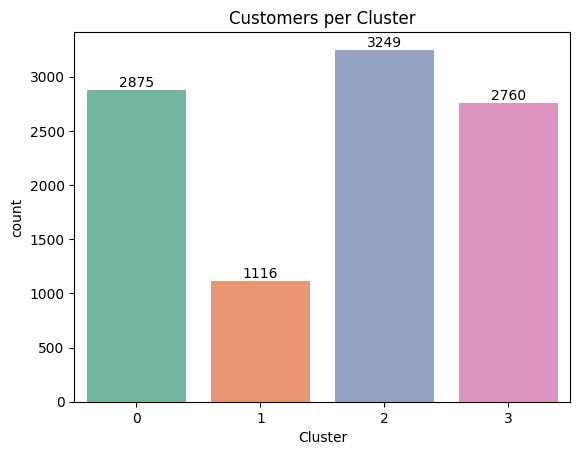

In [ ]:
# visulaise cluster sizes
ax = sns.countplot(
    data=df,
    x="Cluster",
    hue="Cluster",
    palette="Set2",
    legend=False
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (
            p.get_x() + p.get_width()/2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title("Customers per Cluster")
plt.show()

In [11]:
# save cluster dataset
df.to_csv("../data/segmented_bank_churn.csv", index=False)

## Output

The segmented dataset was saved as `segmented_bank_churn.csv` and includes a new `Cluster` column for each customer.